# Análisis de KPIs — Lotería de Cundinamarca

**Autores:** Juan Carlos Díaz González & David Mateo Morales Romero  
**Director:** PhD Jorge Enrique Victorino Guzmán  
**Universidad Central — Maestría en Analítica de Datos**  

---

Este notebook contiene todos los cálculos estadísticos que sustentan los resultados de las **secciones 6.2 y 6.3** del documento de grado. Está organizado en el mismo orden que el documento Word: para cada KPI se presenta el cálculo de umbrales, una celda de texto con los hallazgos y la gráfica correspondiente.

**Archivos requeridos:**
- `Ventas_históricas.csv` — registros transaccionales 2020–2025
- `Proyección_Sorteo.xlsx` — proyecciones por sorteo 2021–2025

> **Instrucción:** Ejecutar las celdas en orden. La Celda 1 solicita los archivos; las demás dependen de que las anteriores hayan corrido exitosamente.

## Configuración y carga de datos

In [1]:
# Carga de archivos en Google Colab
from google.colab import files
print('Seleccione los dos archivos: Ventas_históricas.csv y Proyección_Sorteo.xlsx')
uploaded = files.upload()
print('Archivos cargados:', list(uploaded.keys()))

Seleccione los dos archivos: Ventas_históricas.csv y Proyección_Sorteo.xlsx


Saving Proyección_Sorteo.xlsx to Proyección_Sorteo.xlsx
Saving Ventas históricas.csv to Ventas históricas.csv
Archivos cargados: ['Proyección_Sorteo.xlsx', 'Ventas históricas.csv']


In [2]:
# Instalación de dependencias
!pip install scikit-learn scipy openpyxl matplotlib seaborn -q

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

# Estilo global de gráficos
plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False
})
COLORES = ['#1f6aa5', '#e07b39', '#2e8b57', '#9b2335']

# Constantes metodológicas
UMBRAL_CREMA       = 2.40   # 80% del máximo posible en la matriz CREMA (DAFP, 2018)
UMBRAL_REDUNDANCIA = 0.90   # |r| >= 0.90 implica >81% de varianza compartida (Murad et al., 2022)
ALPHA              = 0.05   # Nivel de significancia estadística
MIN_SORTEOS_ACTIVO = 10     # Mínimo de sorteos para considerar un distribuidor activo

print('Configuración lista.')

Configuración lista.


In [3]:
# Lectura de archivos
# Detección dinámica del nombre del archivo (tolera variaciones de nombre)
nombres = list(uploaded.keys())
archivo_ventas = next((f for f in nombres if 'ventas' in f.lower()), None)
archivo_proy   = next((f for f in nombres if 'proy'   in f.lower()), None)
if not archivo_ventas or not archivo_proy:
    raise FileNotFoundError(f'Archivos no encontrados. Cargados: {nombres}')

df   = pd.read_csv(archivo_ventas, encoding='latin1', sep=None, engine='python')
proy = pd.read_excel(archivo_proy)

# Normalizar nombre de columna año (puede variar según encoding del CSV)
df = df.rename(columns={df.columns[0]: 'Año'})

print(f'Archivo ventas: {archivo_ventas}')
print(f'Dimensiones:    {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Columnas:       {df.columns.tolist()}')
print(f'Período:        {int(df["Año"].min())} – {int(df["Año"].max())}')
print(f'Sorteos:        {df["Sorteo"].nunique():>6}')
print(f'Distribuidores: {df["Distribuidor"].nunique():>6}')
print(f'Departamentos:  {df["Departamento"].nunique():>6}')
print(f'\nArchivo proyección: {archivo_proy}')
print(f'Sorteos con proyección: {proy["sorteo"].nunique()}')

Archivo ventas: Ventas históricas.csv
Dimensiones:    34,562 filas x 17 columnas
Columnas:       ['Año', 'Mes', 'Dia', 'Sorteo', 'Ciudad', 'Departamento', 'Distribuidor', 'Nombre distribuidor', 'Fracciones despachadas', 'Fracciones devueltas', 'Fracciones vendidas', 'Bruto despacho', 'Bruto devuelto', 'Bruto vendido', 'Neto vendido', 'Unnamed: 15', 'Unnamed: 16']
Período:        2020 – 2025
Sorteos:           272
Distribuidores:    412
Departamentos:      33

Archivo proyección: Proyección_Sorteo.xlsx
Sorteos con proyección: 260


In [4]:
# Limpieza y verificación de calidad de datos

# 1. Verificar identidad contable: Despachadas - Devueltas = Vendidas
#    Esta identidad debe cumplirse en cada sorteo; desviaciones indican
#    errores de registro o redondeos en el sistema fuente.
chk = df.groupby('Sorteo').agg(
    d  =('Fracciones despachadas','sum'),
    dev=('Fracciones devueltas',  'sum'),
    v  =('Fracciones vendidas',   'sum')
).reset_index()
chk['diferencia'] = abs((chk['d'] - chk['dev']) - chk['v'])
chk['ok'] = chk['diferencia'] <= 5  # tolerancia de 5 fracciones por sorteo

print('=== Verificación de identidad contable ===')
print(f'  Sorteos evaluados:   {len(chk)}')
print(f'  Sorteos OK:          {chk["ok"].sum()} ({chk["ok"].mean()*100:.1f}%)')
print(f'  Sorteos con error:   {(~chk["ok"]).sum()}')
if (~chk['ok']).sum() > 0:
    print('  Sorteos con diferencia > 5 fracciones:')
    print(chk[~chk['ok']][['Sorteo','d','dev','v','diferencia']].to_string(index=False))
print()

# 2. Valores nulos por columna
nulos = df.isnull().sum()
nulos_con_datos = nulos[nulos > 0]
print('=== Valores nulos ===')
if len(nulos_con_datos) == 0:
    print('  Ninguna columna tiene valores nulos.')
else:
    print(nulos_con_datos.to_string())
print()

# Rellenar nombres nulos antes de recortar (evita TypeError: 'value' must be str or bytes)
df['Nombre distribuidor'] = df['Nombre distribuidor'].fillna('Sin nombre')

# 3. Estadísticos descriptivos de columnas numéricas clave
cols_num = ['Fracciones despachadas','Fracciones devueltas','Fracciones vendidas',
            'Bruto vendido','Neto vendido']
print('=== Estadísticos descriptivos (columnas clave) ===')
display(df[cols_num].describe().applymap(lambda x: f'{x:,.0f}'))
print()

# 4. Distribución de registros por año
print('=== Registros por año ===')
print(df.groupby('Año').agg(
    registros=('Sorteo','count'),
    sorteos=('Sorteo','nunique'),
    distribuidores=('Distribuidor','nunique')
).to_string())

=== Verificación de identidad contable ===
  Sorteos evaluados:   272
  Sorteos OK:          271 (99.6%)
  Sorteos con error:   1
  Sorteos con diferencia > 5 fracciones:
 Sorteo      d    dev      v  diferencia
   4705 883632 696442 187315         125

=== Valores nulos ===
Nombre distribuidor      134
Unnamed: 15            34562
Unnamed: 16            34561

=== Estadísticos descriptivos (columnas clave) ===


,Fracciones despachadas,Fracciones devueltas,Fracciones vendidas,Bruto vendido,Neto vendido
count,"34,562","34,562","34,562","34,562","34,562"
mean,"5,998","4,603","1,395","6,867,178","5,149,647"
std,"13,974","11,819","2,551","12,595,668","9,446,677"
min,2,0,-581,"-2,324,000","-1,743,000"
25%,"1,320",869,322,"1,570,000","1,177,500"
50%,"2,700","1,938",643,"3,180,000","2,385,000"
75%,"5,520","4,109","1,264","6,245,000","4,683,000"
max,"238,170","234,078","31,175","127,845,000","95,883,750"



=== Registros por año ===
      registros  sorteos  distribuidores
Año                                     
2020       5456       45             135
2021       6542       52             132
2022       6678       52             138
2023       6747       52             387
2024       6829       53             136
2025       2310       18             131


---
## Sección 6.2 — Formulación y Definición Analítica de KPIs


---
### 6.2.3 — Fichas técnicas: estadísticos históricos y umbrales

Los umbrales semáforo se determinan con los **percentiles P25 (umbral de alerta) y P75 (meta)** de la distribución histórica del período 2020–2025, conforme a la metodología de Nicolao García y Morcela (2015, págs. 9 y 13). Este enfoque garantiza que las metas sean *valores probables* anclados en el comportamiento real del proceso, evitando tanto la subestimación como la sobreestimación.

#### **KPI-COM-01 — Tasa de Venta Efectiva (TVE%)**

**Interpretación:** Mide qué proporción de las fracciones despachadas a la red se convierte efectivamente en venta. Un valor bajo indica que la Subgerencia Comercial está enviando más producto del que el mercado absorbe. **Se maximiza.** El umbral verde (meta) corresponde al P75 histórico.

In [5]:
# KPI-COM-01: TVE% — cálculo de umbrales
# La TVE se calcula a nivel sorteo: suma de fracciones vendidas / suma despachadas
# El agrupamiento por sorteo agrega todos los distribuidores y departamentos de ese sorteo.
# La granularidad correcta para los umbrales es el SORTEO (unidad de negocio)

# 1. Agregación de datos por Sorteo y Año
# Agrupamos para obtener el total de ventas y despachos por cada evento individual
df_tve = df.groupby(['Sorteo','Año']).agg(
    v=('Fracciones vendidas', 'sum'),
    d=('Fracciones despachadas', 'sum')
).reset_index()

# 2. Cálculo del KPI: Tasa de Venta Efectiva (TVE)
# Representa qué porcentaje del inventario enviado a la red fue realmente vendido
df_tve['TVE'] = df_tve['v'] / df_tve['d']  # Resultado decimal (ej: 0.25 para 25%)
tve = df_tve['TVE']

# 3. Análisis de Umbrales Estadísticos (Benchmarking)
tve_p25 = tve.quantile(0.25)  # umbral de alerta (rojo), El 25% de los peores sorteos están por debajo de este valor
tve_p75 = tve.quantile(0.75)  # meta (verde), El 25% de los mejores sorteos superan este valor (objetivo)

# 4. Reporte de Métricas por Consola
print('KPI-COM-01 — Tasa de Venta Efectiva (TVE%)')
print(f'  Fórmula:  Fracciones Vendidas / Fracciones Despachadas × 100')
print(f'  Nivel de cálculo: sorteo (n = {len(tve)} sorteos)')
print()

# Estadísticos descriptivos básicos
print(f'  Mínimo histórico:  {tve.min()*100:.1f}%')
print(f'  P25 (umbral rojo): {tve_p25*100:.1f}%  ← alerta: la red convierte menos del 22% del despacho')
print(f'  Mediana histórica: {tve.median()*100:.1f}%')
print(f'  P75 (meta verde):  {tve_p75*100:.1f}%  ← meta: el 25% mejor de sorteos supera este valor')
print(f'  Máximo histórico:  {tve.max()*100:.1f}%')

# Coeficiente de Variación (CV): Mide qué tan estable es el KPI en el tiempo
# Un CV bajo indica ventas constantes; un CV alto indica mucha incertidumbre
print(f'  CV:                {tve.std()/tve.mean()*100:.1f}%  (variabilidad intertemporal moderada)')
print()

KPI-COM-01 — Tasa de Venta Efectiva (TVE%)
  Fórmula:  Fracciones Vendidas / Fracciones Despachadas × 100
  Nivel de cálculo: sorteo (n = 272 sorteos)

  Mínimo histórico:  5.9%
  P25 (umbral rojo): 22.3%  ← alerta: la red convierte menos del 22% del despacho
  Mediana histórica: 23.7%
  P75 (meta verde):  26.2%  ← meta: el 25% mejor de sorteos supera este valor
  Máximo histórico:  34.2%
  CV:                17.4%  (variabilidad intertemporal moderada)



TVE%: evolución de la mediana por año
Lotería de Cundinamarca, 2020–2025


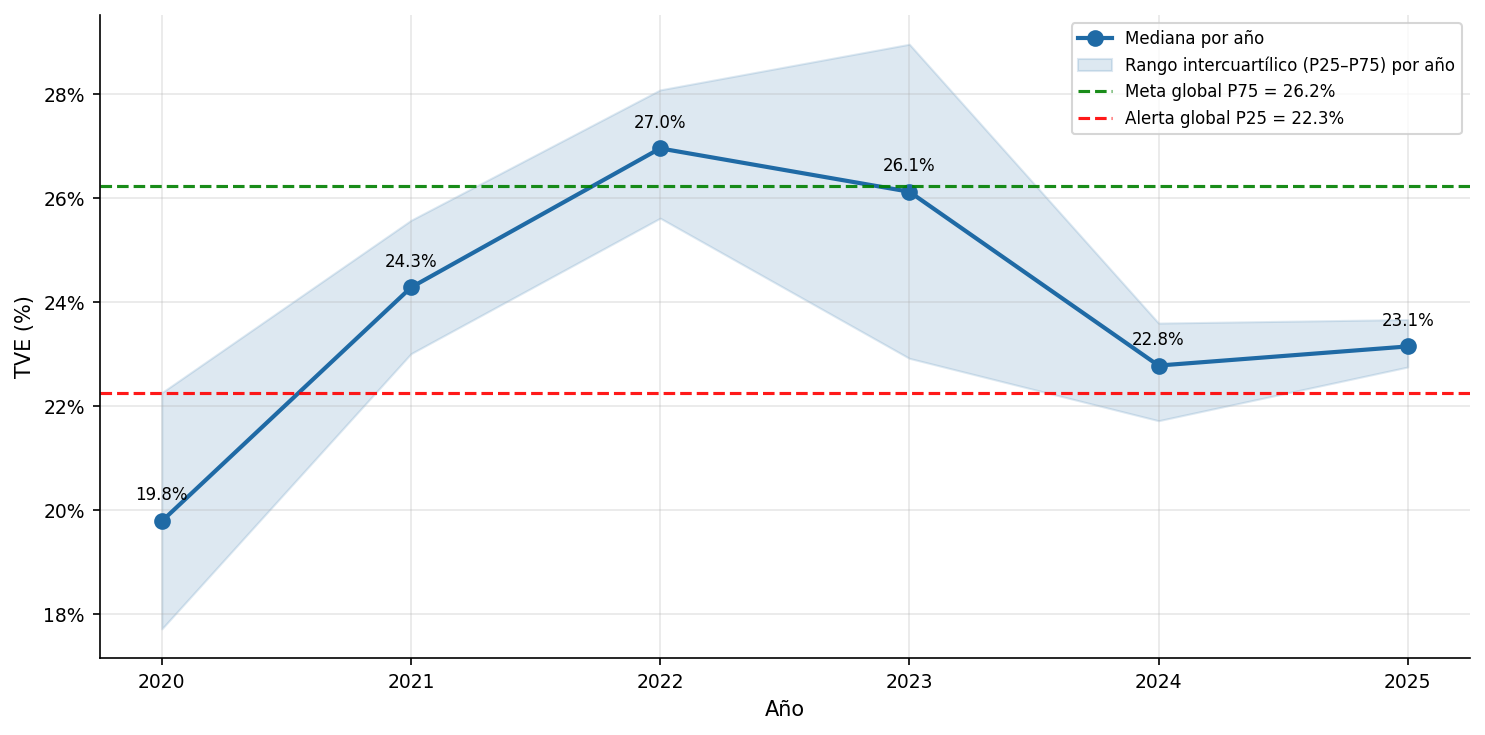

Guardado: Figura1_TVE_evolucion.png


In [20]:
# Gráfico de evolución temporal de la TVE%
fig, ax = plt.subplots(figsize=(10, 5))

# Agregación por año para calcular la tendencia y la dispersión anual
tve_yr = df_tve.groupby('Año')['TVE'].agg(
    mediana='median',               # Punto central de la línea
    p25=lambda x: x.quantile(0.25), # Límite inferior del área sombreada
    p75=lambda x: x.quantile(0.75)  # Límite superior del área sombreada
).reset_index()

# Dibujar la línea de la mediana y el área de dispersión (IQR anual)
ax.plot(tve_yr['Año'], tve_yr['mediana']*100, marker='o', color=COLORES[0], lw=2, ms=7, label='Mediana por año')
ax.fill_between(tve_yr['Año'], tve_yr['p25']*100, tve_yr['p75']*100,
                alpha=0.15, color=COLORES[0], label='Rango intercuartílico (P25–P75) por año')

# Paso 3: Dibujar los umbrales de control GLOBALES (Benchmarks de toda la historia)
# Estas líneas permiten ver si el desempeño de un año específico fue "bueno" o "malo" respecto al total
ax.axhline(tve_p75*100, color='green', ls='--', lw=1.5, alpha=0.9,
           label=f'Meta global P75 = {tve_p75*100:.1f}%')
ax.axhline(tve_p25*100, color='red',   ls='--', lw=1.5, alpha=0.9,
           label=f'Alerta global P25 = {tve_p25*100:.1f}%')

# Anotar los valores exactos sobre cada punto para facilitar la lectura
for _, row in tve_yr.iterrows():
    ax.annotate(f'{row["mediana"]*100:.1f}%',
                (row['Año'], row['mediana']*100),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

# Título y subtítulo por fuera del gráfico (para no repetir en el informe)
print('TVE%: evolución de la mediana por año')
print('Lotería de Cundinamarca, 2020–2025')

# Formateo estético del gráfico
# ax.set_title('TVE%: evolución de la mediana por año\nLotería de Cundinamarca, 2020–2025', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('TVE (%)')
ax.set_xticks(tve_yr['Año'])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('Figura1_TVE_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: Figura1_TVE_evolucion.png')

##### Hallazgos KPI-COM-01 (TVE%)

El análisis de la **Tasa de Venta Efectiva (TVE%)** permite diagnosticar la eficiencia de la red de ventas al contrastar el despacho contra la venta real. A continuación, se detallan los hallazgos clave derivados de la **Figura**:

### 1. Diagnóstico de Eficiencia Histórica
* **Umbrales de Control:** Los límites establecidos (**Alerta P25: 22.3%** y **Meta P75: 26.2%**) son estadísticamente robustos. El hecho de que el 50% central de los sorteos históricos se ubique entre estas líneas confirma que son objetivos operativamente alcanzables y realistas para la operación.
* **Estabilidad:** El Coeficiente de Variación (**17.4%**) sugiere una variabilidad intertemporal moderada, lo que permite confiar en la mediana como un indicador fiel de la tendencia.

### 2. Evolución y Puntos de Inflexión
* **Ciclo de Auge (2020–2022):** Se identifica una recuperación sostenida post-pandemia, donde la mediana pasó de **19.8%** a un máximo histórico de **27.0%**. En 2022, la operación logró superar consistentemente la meta global.
* **Contracción Crítica (2023–2024):** A partir de 2023 se observa un quiebre de tendencia. La caída hacia un **22.8%** en 2024 sitúa a la Lotería en el límite del **umbral de alerta rojo**. Este descenso es coherente con el **IRVE de 0.82** reportado en el Informe de Gestión 2024.
* **Situación Actual (2025):** Con un dato parcial de **23.1%**, la eficiencia se ha estabilizado, pero permanece por debajo de la mediana histórica (**23.7%**), indicando que la red aún no recupera la inercia de años anteriores.

---

### Recomendaciones de Mejora Futura
1.  **Implementación de Umbrales Dinámicos:** Se sugiere evolucionar hacia metas basadas en **ventanas móviles (últimos 12 a 24 meses)**. Esto permitiría ajustar las expectativas comerciales a la coyuntura económica actual, evitando el uso de metas de 2022 que podrían estar desactualizadas frente al mercado presente.
2.  **Auditoría de Dispersión:** La reducción del rango intercuartílico en los últimos años sugiere que la baja eficiencia es sistémica. Se recomienda identificar los distribuidores con desempeño persistente bajo el **22.3%** para ajustar los cupos de despacho.

#### **KPI-TER-01 — Índice Herfindahl-Hirschman Territorial (HHI)**

**Interpretación del indicador:** El HHI es un índice de concentración: suma los cuadrados de las participaciones de cada departamento en el neto vendido del sorteo. Un HHI alto indica que pocos departamentos concentran la mayor parte de las ventas (riesgo de dependencia territorial); un HHI bajo indica una distribución más diversificada.  

**Lectura global vs. por departamento:** El HHI es un indicador *global* del sorteo — produce un único número por sorteo que resume la distribución entre todos los departamentos. No se descompone por departamento. Lo que sí se analiza por departamento es la **participación individual** de cada uno, que es el insumo para calcular el HHI. La tabla completa de participaciones permite identificar qué territorios impulsan o reducen el índice.  

**Se minimiza.** El umbral verde (meta) corresponde al P25 histórico (menor concentración) y el umbral rojo al P75 (mayor concentración), invirtiendo la lógica convencional.

In [7]:
# KPI-TER-01: HHI — cálculo global y por sorteo
# Este índice mide la concentración de ventas. Entre más bajo, más repartido está el riesgo.

# Paso 1: Calcular la participación de cada departamento por sorteo
# Agrupamos ventas por sorteo y departamento
df_d = df.groupby(['Sorteo','Año','Departamento'])['Neto vendido'].sum().reset_index()
# Calculamos el total vendido de cada sorteo (para usarlo como denominador)
tot = df_d.groupby('Sorteo')['Neto vendido'].sum().reset_index(name='total')
df_d = df_d.merge(tot, on='Sorteo')
# Participación: qué porcentaje del sorteo vendió cada departamento (0 a 1)
df_d['participacion'] = df_d['Neto vendido'] / df_d['total']

# Paso 2: Calcular el HHI por sorteo
# La fórmula es la suma de los cuadrados de las participaciones.
# Un HHI = 1 significa monopolio (un solo depto vende todo)
# Un HHI = 1/N significa distribución perfectamente equitativa entre N deptos
# Si el HHI sube, la lotería depende de menos departamentos (riesgo alto).
hhi = df_d.groupby(['Sorteo','Año']).apply(
    lambda x: (x['participacion']**2).sum()
).reset_index(name='HHI')
h = hhi['HHI']

# Paso 3: Definir Umbrales de Control (Lógica Inversa)
# En HHI, lo "bueno" es el valor bajo. Por eso:
# P25 (valor pequeño) = Meta Verde | P75 (valor alto) = Alerta Roja
hhi_p25 = h.quantile(0.25)  # meta verde (diversificación lograda)
hhi_p75 = h.quantile(0.75)  # umbral rojo (concentración excesiva)

print('KPI-TER-01 — Índice HHI Territorial')
print(f'  Fórmula:  Σ (Participación_depto_i²)')
print(f'  Nivel de cálculo: sorteo (n = {len(h)} sorteos, se minimiza)')
print()

print(f'  Mínimo histórico:           {h.min()*100:.2f}%  (máxima diversificación observada)')
print(f'  P25 (meta verde):           {hhi_p25*100:.2f}%  ← sorteos con buena diversificación territorial')
print(f'  Mediana histórica:          {h.median()*100:.2f}%')
print(f'  P75 (umbral rojo):          {hhi_p75*100:.2f}%  ← alerta: concentración geográfica elevada')
print(f'  Máximo histórico:           {h.max()*100:.2f}%  (mínima diversificación observada)')
print(f'  CV:                         {h.std()/h.mean()*100:.1f}%')
print()

KPI-TER-01 — Índice HHI Territorial
  Fórmula:  Σ (Participación_depto_i²)
  Nivel de cálculo: sorteo (n = 272 sorteos, se minimiza)

  Mínimo histórico:           10.59%  (máxima diversificación observada)
  P25 (meta verde):           13.24%  ← sorteos con buena diversificación territorial
  Mediana histórica:          13.69%
  P75 (umbral rojo):          14.36%  ← alerta: concentración geográfica elevada
  Máximo histórico:           20.05%  (mínima diversificación observada)
  CV:                         8.2%



In [8]:
# HHI: participación acumulada por departamento (tabla completa)

# Esta tabla muestra el insumo base del HHI: la participación de cada departamento
# en el neto vendido total del período 2020-2025 (suma acumulada, no promedio)

total_neto = df['Neto vendido'].sum()
tabla_deptos = (
    df.groupby('Departamento')['Neto vendido'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
tabla_deptos['Participación (%)']      = tabla_deptos['Neto vendido'] / total_neto * 100
tabla_deptos['Participación acum. (%)'] = tabla_deptos['Participación (%)'].cumsum()
tabla_deptos['Neto vendido (COP M)']   = tabla_deptos['Neto vendido'] / 1e6
tabla_deptos['Contribución al HHI']    = (tabla_deptos['Participación (%)'] / 100)**2

print('Tabla — Participación territorial en Neto Vendido acumulado 2020–2025')
print('(Esta tabla es el insumo del HHI: concentrar la columna Contribución al HHI indica alta concentración)')
print()
display(tabla_deptos[['Departamento','Neto vendido (COP M)','Participación (%)','Participación acum. (%)','Contribución al HHI']]
        .style.format({
            'Neto vendido (COP M)':     '{:,.1f}',
            'Participación (%)':        '{:.2f}%',
            'Participación acum. (%)':  '{:.1f}%',
            'Contribución al HHI':      '{:.5f}'
        }))
print()
print(f'HHI acumulado global (suma de contribuciones): {tabla_deptos["Contribución al HHI"].sum()*100:.2f}%')
print(f'Interpretación: los 3 primeros departamentos explican {tabla_deptos["Contribución al HHI"].head(3).sum()/tabla_deptos["Contribución al HHI"].sum()*100:.0f}% del HHI total')

Tabla — Participación territorial en Neto Vendido acumulado 2020–2025
(Esta tabla es el insumo del HHI: concentrar la columna Contribución al HHI indica alta concentración)



,Departamento,Neto vendido (COP M),Participación (%),Participación acum. (%),Contribución al HHI
0,"BOGOTA, DISTRITO CAPITAL","48,705.2",27.37%,27.4%,0.07489
1,ANTIOQUIA,"33,131.9",18.62%,46.0%,0.03465
2,VALLE DEL CAUCA,"23,650.3",13.29%,59.3%,0.01766
3,ATLANTICO,"8,100.5",4.55%,63.8%,0.00207
4,SANTANDER,"7,013.2",3.94%,67.8%,0.00155
5,BOLIVAR,"6,459.7",3.63%,71.4%,0.00132
6,META,"4,935.8",2.77%,74.2%,0.00077
7,CUNDINAMARCA,"4,355.8",2.45%,76.6%,0.00060
8,CESAR,"4,100.3",2.30%,78.9%,0.00053
9,CORDOBA,"3,878.4",2.18%,81.1%,0.00047



HHI acumulado global (suma de contribuciones): 13.70%
Interpretación: los 3 primeros departamentos explican 93% del HHI total


HHI Territorial: evolución y distribución
Lotería de Cundinamarca, 2020–2025


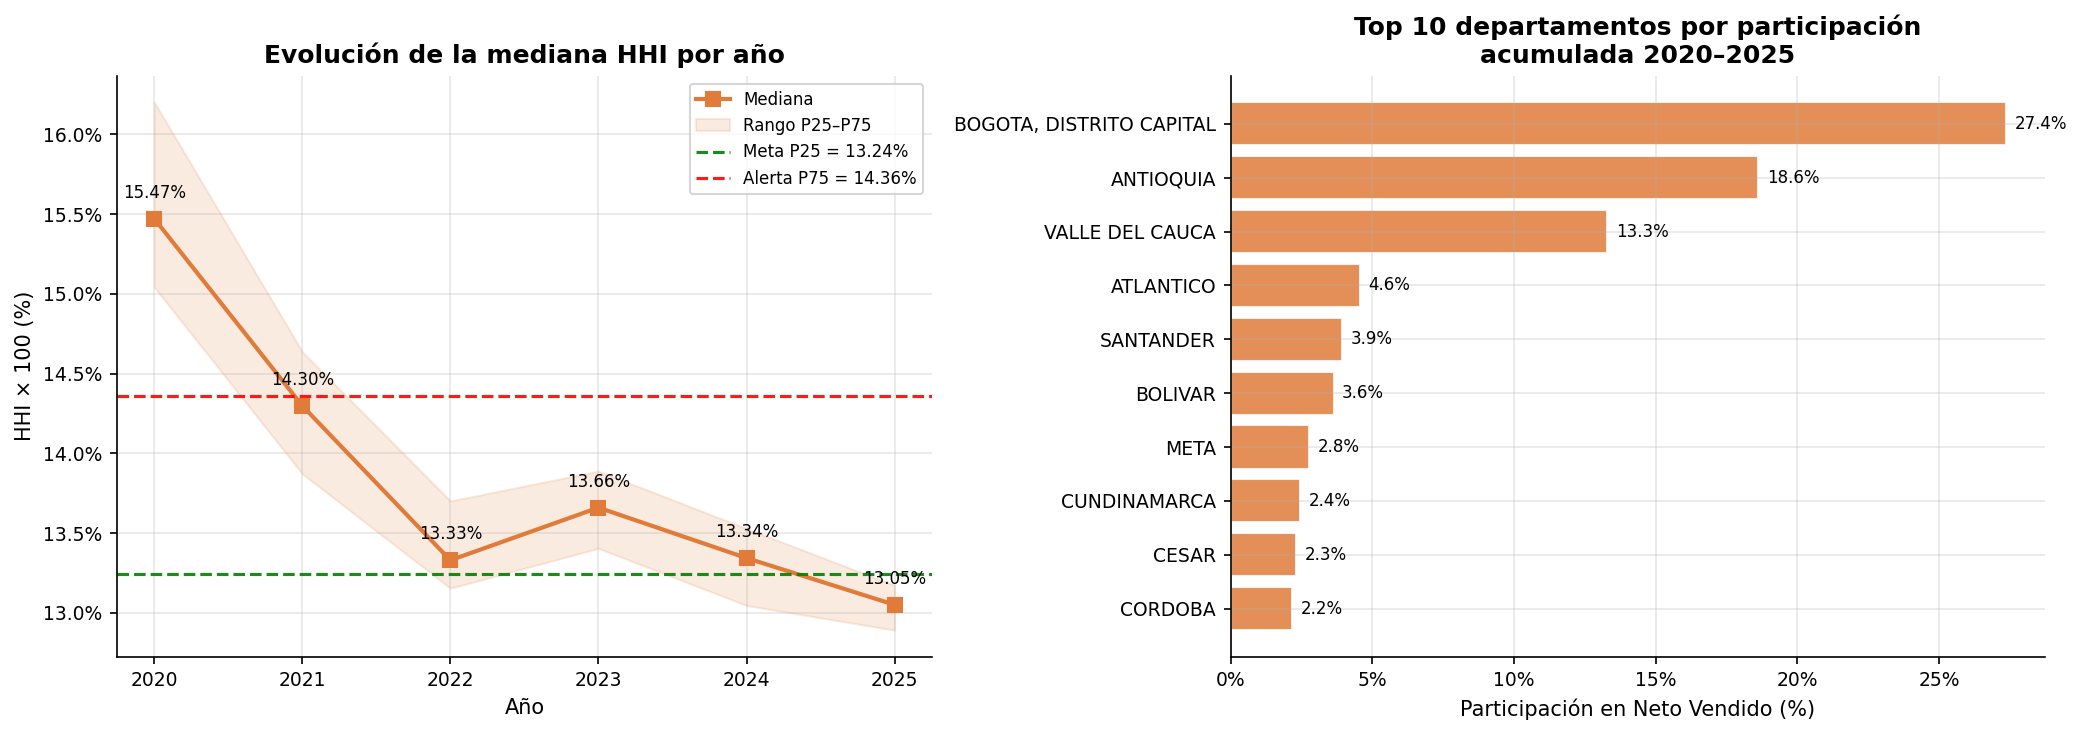

Guardado: Figura2_HHI.png


In [22]:
# Gráfico HHI: Evolución Temporal y Composición Territorial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Título y subtítulo por fuera del gráfico (para no repetir en el informe)
print('HHI Territorial: evolución y distribución')
print('Lotería de Cundinamarca, 2020–2025')
#fig.suptitle('HHI Territorial: evolución y distribución\nLotería de Cundinamarca, 2020–2025',
#             fontweight='bold', fontsize=12)

# Panel izquierdo: evolución temporal
ax = axes[0]
hhi_yr = hhi.groupby('Año')['HHI'].agg(
    mediana='median', p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
).reset_index()

# Dibujamos la tendencia y el área de dispersión (Sombreado)
ax.plot(hhi_yr['Año'], hhi_yr['mediana']*100, marker='s', color=COLORES[1], lw=2, ms=7, label='Mediana')
ax.fill_between(hhi_yr['Año'], hhi_yr['p25']*100, hhi_yr['p75']*100,
                alpha=0.15, color=COLORES[1], label='Rango P25–P75')

# Líneas de meta y alerta (Invertidas respecto a TVE)
ax.axhline(hhi_p25*100, color='green', ls='--', lw=1.5, alpha=0.9,
           label=f'Meta P25 = {hhi_p25*100:.2f}%')
ax.axhline(hhi_p75*100, color='red',   ls='--', lw=1.5, alpha=0.9,
           label=f'Alerta P75 = {hhi_p75*100:.2f}%')

# Etiquetas de datos
for _,row in hhi_yr.iterrows():
    ax.annotate(f'{row["mediana"]*100:.2f}%', (row['Año'], row['mediana']*100),
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=8)

ax.set_title('Evolución de la mediana HHI por año', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('HHI × 100 (%)')
ax.set_xticks(hhi_yr['Año'])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=1))
ax.legend(fontsize=8)

# Panel derecho: top 10 departamentos por participación
ax2 = axes[1]
# Tomamos los 10 departamentos con más ventas históricas
top10 = tabla_deptos.head(10).sort_values('Participación (%)', ascending=True)
bars = ax2.barh(top10['Departamento'], top10['Participación (%)'],
               color=COLORES[1], alpha=0.85, edgecolor='white')

# Añadir el % de participación al final de cada barra
for bar,val in zip(bars, top10['Participación (%)']):
    ax2.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)


ax2.set_title('Top 10 departamentos por participación\nacumulada 2020–2025', fontweight='bold')
ax2.set_xlabel('Participación en Neto Vendido (%)')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))

plt.tight_layout()
plt.savefig('Figura2_HHI.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: Figura2_HHI.png')

##### Hallazgos KPI-TER-01 (Concentración HHI)

El **Índice Herfindahl-Hirschman (HHI)** mide el grado de diversificación geográfica de las ventas. Un índice bajo indica una red robusta y menos dependiente de territorios específicos.

### 1. Diagnóstico de Concentración Territorial
* **Inversión de Umbrales:** Para este KPI, la lógica se invierte: la **Meta (P25: 13.24%)** representa los niveles de mayor diversificación, mientras que la **Alerta (P75: 14.36%)** señala sorteos con concentración excesiva.
* **Dominio del Mercado:** La tabla de participación acumulada revela que solo tres territorios (**Bogotá D.C., Antioquia y Valle del Cauca**) concentran el **59.3%** de las ventas totales. La contribución de Bogotá al HHI (0.074) es el principal factor de riesgo en la métrica global.

### 2. Evolución y Diversificación
* **Tendencia Positiva:** Se observa una **desconcentración progresiva** y exitosa. El HHI (mediana) descendió de un **15.47% (2020)** a un **13.05% (2025)**.
* **Hito de Gestión:** A partir de 2022, la mediana del HHI se ha mantenido consistentemente por debajo o muy cerca de la **Meta (13.24%)**, lo que indica que la estrategia de expansión territorial ha sido efectiva en reducir la dependencia de la capital.
* **Estabilidad Geográfica:** El bajo Coeficiente de Variación (**8.2%**) confirma que la estructura de ventas territoriales es muy estable y que los cambios logrados son estructurales, no fortuitos.

---

### Recomendaciones de Mejora Futura
1. **Monitoreo de "Colas" de Mercado:** Aunque el HHI ha bajado, el Top 10 de departamentos concentra casi el 80% de la venta. Se recomienda incentivar el crecimiento en los departamentos del puesto 11 en adelante para "empujar" el HHI hacia el **10.0%** (máxima diversificación teórica observada).
2. **HHI por Canal:** Sería valioso calcular este índice diferenciando entre "Venta Física" y "Venta Virtual". Es probable que la venta virtual presente una mayor concentración que la física, lo que representaría un riesgo oculto en la digitalización.

#### **KPI-DIST-01 — Productividad Comercial por Distribuidor**

**Fórmula institucional:**

$$\text{Productividad} = \frac{\text{Neto Vendido}}{\text{Total Sorteos} \times \text{Total Fracciones Despachadas}}$$

**Interpretación:** Mide el ingreso neto generado por fracción despachada, normalizado por el número de sorteos del período. A mayor valor, mayor rendimiento económico por unidad distribuida. Permite comparar la eficiencia económica entre distribuidores dentro de un mismo año. **Se maximiza.**

**Umbrales semáforo:** Se calculan como el P25 (rojo) y P75 (verde) de la distribución de distribuidores activos (≥10 sorteos), en coherencia con el criterio estadístico aplicado a los demás KPIs. La relación de este KPI con los demás se evaluará en la sección 6.3.

In [10]:
# KPI-DIST-01 — Productividad Comercial por Distribuidor
# Fórmula: Neto Vendido / (Total Sorteos × Total Fracciones Despachadas)
# Fuente: Fact_Ventas — campos neto_vendido, sorteo, cantidad_despachada, id_distribuidor

# ── Paso 1: Agregar por distribuidor ────────────────────────────────────────────
# Se suman neto vendido y fracciones despachadas en todo el período,
# y se cuentan los sorteos únicos en los que participó cada distribuidor.
prod = df.groupby('Distribuidor').agg(
    neto       = ('Neto vendido',           'sum'),
    sorteos    = ('Sorteo',                 'nunique'),
    fracc_desp = ('Fracciones despachadas', 'sum'),
    nombre     = ('Nombre distribuidor',    'first')
).reset_index()

# ── Paso 2: Aplicar fórmula institucional ───────────────────────────────────────
prod['productividad'] = prod['neto'] / (prod['sorteos'] * prod['fracc_desp'])

# ── Paso 3: Filtrar distribuidores activos (≥10 sorteos) ────────────────────────
# Los distribuidores ocasionales participan en pocos sorteos, lo que genera valores
# extremos que distorsionan los umbrales semáforo (el denominador es muy pequeño).
# El umbral de 10 sorteos garantiza estabilidad estadística mínima en la serie del distribuidor.
MIN_SORTEOS = 10
prod_activos = prod[prod['sorteos'] >= MIN_SORTEOS].copy()

n_total    = len(prod)
n_activos  = len(prod_activos)
n_ocas     = n_total - n_activos

# ── Paso 4: Calcular estadísticos y umbrales semáforo ──────────────────────────
# Los umbrales P25 (rojo) y P75 (verde) se calculan sobre distribuidores activos,
# siguiendo el mismo criterio estadístico aplicado a los demás KPIs.
prod_p25 = prod_activos['productividad'].quantile(0.25)
prod_p75 = prod_activos['productividad'].quantile(0.75)
prod_med = prod_activos['productividad'].median()
prod_media = prod_activos['productividad'].mean()
prod_cv  = prod_activos['productividad'].std() / prod_media * 100

print('KPI-DIST-01 — Productividad Comercial por Distribuidor')
print(f'  Fórmula:  Neto Vendido / (Total Sorteos × Fracciones Despachadas)')
print(f'  Unidad:   COP por fracción despachada')
print()

print(f'  Distribuidores totales:    {n_total}')
print(f'  Activos (≥{MIN_SORTEOS} sorteos):    {n_activos}  ← base para umbrales')
print(f'  Ocasionales (<{MIN_SORTEOS} sorteos): {n_ocas}  ← excluidos del semáforo por baja estabilidad')
print()

print(f'  Estadísticos (distribuidores activos):')
print(f'    Mínimo:   {prod_activos["productividad"].min():.4f} COP/fracc')
print(f'    P25:      {prod_p25:.4f} COP/fracc  ← umbral rojo semáforo')
print(f'    Mediana:  {prod_med:.4f} COP/fracc')
print(f'    P75:      {prod_p75:.4f} COP/fracc  ← umbral verde semáforo (meta)')
print(f'    Máximo:   {prod_activos["productividad"].max():.4f} COP/fracc')
print(f'    CV:       {prod_cv:.1f}%')

KPI-DIST-01 — Productividad Comercial por Distribuidor
  Fórmula:  Neto Vendido / (Total Sorteos × Fracciones Despachadas)
  Unidad:   COP por fracción despachada

  Distribuidores totales:    412
  Activos (≥10 sorteos):    157  ← base para umbrales
  Ocasionales (<10 sorteos): 255  ← excluidos del semáforo por baja estabilidad

  Estadísticos (distribuidores activos):
    Mínimo:   1.8161 COP/fracc
    P25:      2.7667 COP/fracc  ← umbral rojo semáforo
    Mediana:  3.7694 COP/fracc
    P75:      7.2948 COP/fracc  ← umbral verde semáforo (meta)
    Máximo:   416.6667 COP/fracc
    CV:       333.0%


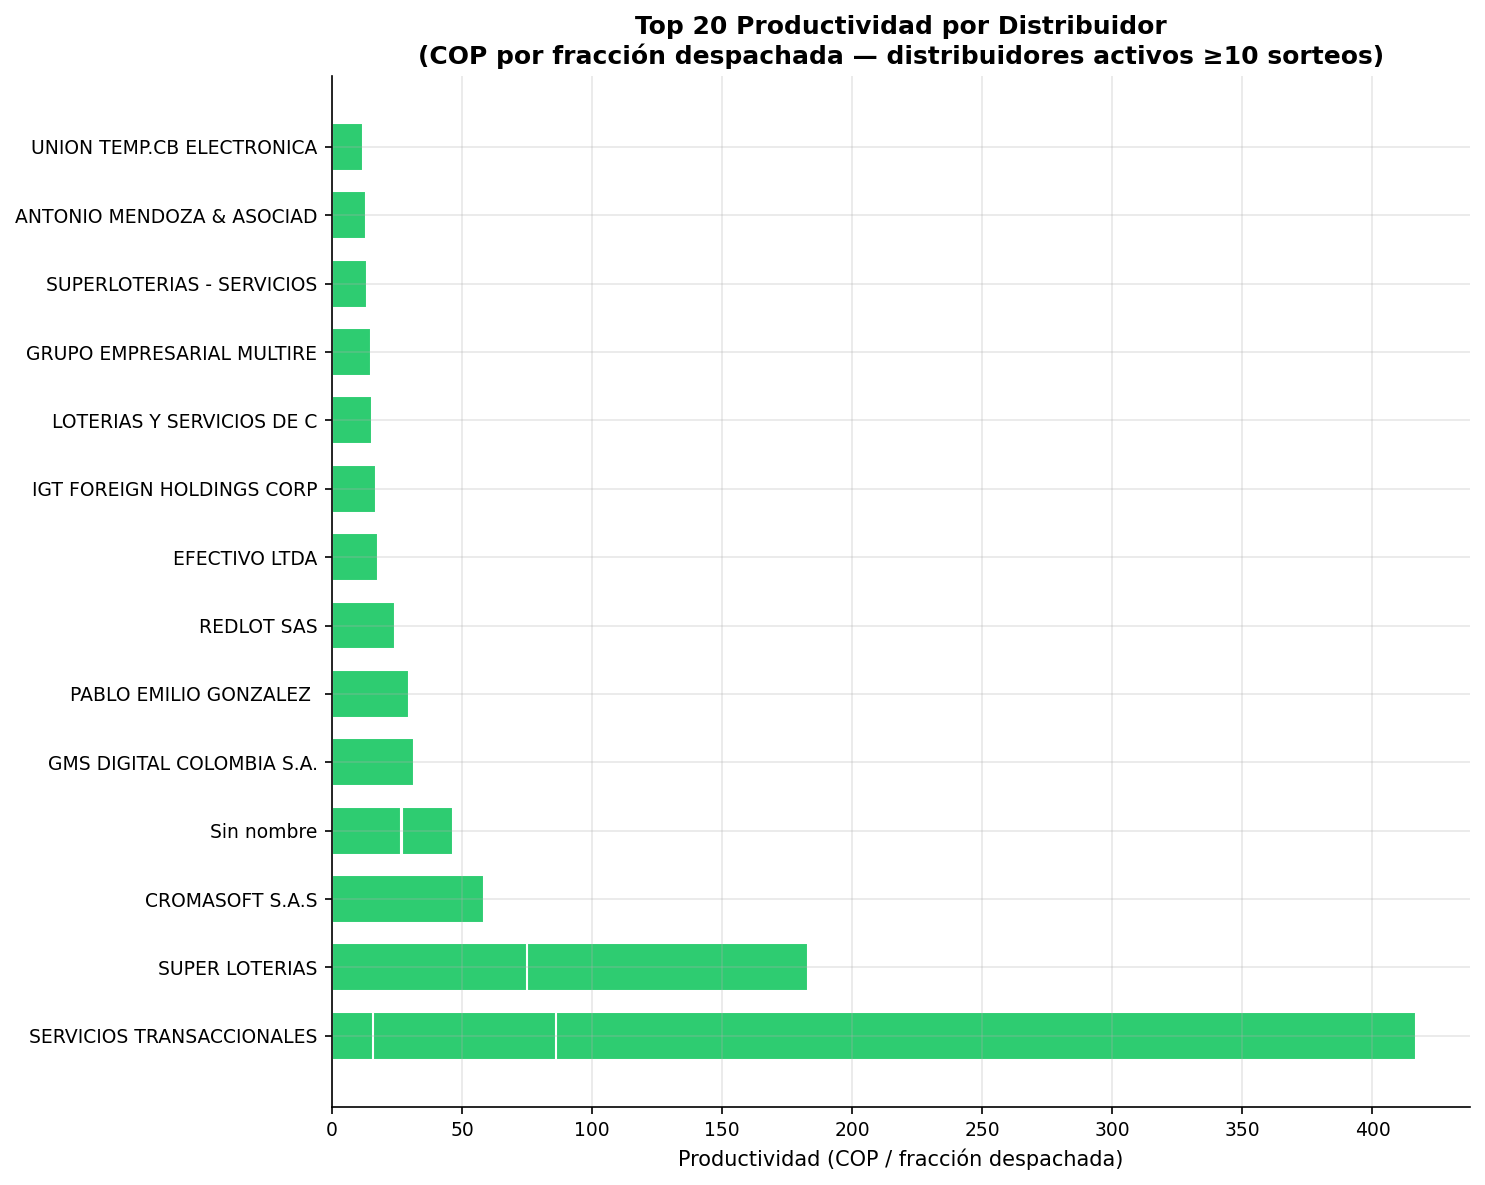

Guardado: Figura3_Productividad.png


In [11]:
# Top Productividad por Distribuidores activos
# Se muestran los 20 distribuidores activos con mayor productividad.
# Los nombres se recortan a 25 caracteres para legibilidad en el eje Y.

TOP_N = 20
# Ordenar descendente: el mayor queda en la parte superior del gráfico
df_plot = prod_activos.nlargest(TOP_N, 'productividad').sort_values('productividad', ascending=False)

# Recortar nombres largos
df_plot = df_plot.copy()
df_plot['nombre_corto'] = df_plot['nombre'].str[:25]

# Asignar color según semáforo
def color_semaforo(v):
    if v >= prod_p75: return '#2ecc71'   # verde
    elif v >= prod_p25: return '#f39c12' # amarillo
    else: return '#e74c3c'               # rojo

colores = [color_semaforo(v) for v in df_plot['productividad']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(df_plot['nombre_corto'], df_plot['productividad'],
               color=colores, edgecolor='white', height=0.7)

# Líneas de umbral
#ax.axvline(prod_p25, color='red',   linestyle='--', linewidth=1.2,
#           label=f'P25 (rojo) = {prod_p25:.2f}')
#ax.axvline(prod_p75, color='green', linestyle='--', linewidth=1.2,
#           label=f'P75 (verde) = {prod_p75:.2f}')

ax.set_title(f'Top {TOP_N} Productividad por Distribuidor\n'
             '(COP por fracción despachada — distribuidores activos ≥10 sorteos)',
             fontweight='bold')
ax.set_xlabel('Productividad (COP / fracción despachada)')
ax.set_ylabel('')
#ax.legend(loc='lower right')
ax.legend().set_visible(False)
plt.tight_layout()
plt.savefig('Figura3_Productividad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: Figura3_Productividad.png')

Distribución de Productividad — 157 distribuidores activos (≥10 sorteos)
(12 distribuidores con productividad > 20 COP/fracc omitidos del eje — incluidos en el cálculo de umbrales)


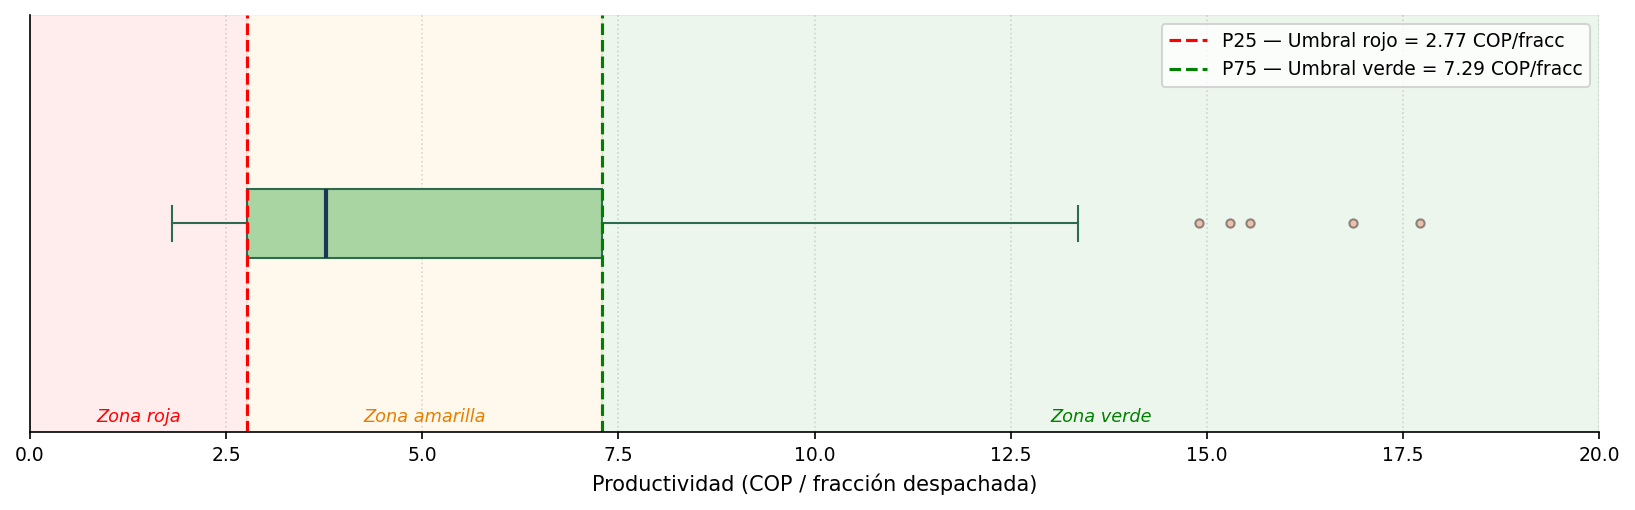


Nota: 7 distribuidores con productividad > 36.5 COP/fracc omitidos del eje (outliers extremos). Incluidos en el cálculo de umbrales.


In [24]:
# Boxplot distribución completa de distribuidores activos
# Muestra los 157 distribuidores activos con los umbrales P25 y P75 superpuestos,
# permitiendo visualizar cómo los umbrales semáforo dividen la distribución real.

fig, ax = plt.subplots(figsize=(11, 3.5))

# Boxplot horizontal
ax.boxplot(
    prod_activos['productividad'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#a8d5a2', color='#2d6a4f'),
    medianprops=dict(color='#1d3557', linewidth=2),
    whiskerprops=dict(color='#2d6a4f'),
    capprops=dict(color='#2d6a4f'),
    flierprops=dict(marker='o', color='#e76f51', alpha=0.4,
                    markersize=4, markerfacecolor='#e76f51')
)

# Líneas de umbral
ax.axvline(prod_p25, color='red',   linestyle='--', linewidth=1.5,
           label=f'P25 — Umbral rojo = {prod_p25:.2f} COP/fracc')
ax.axvline(prod_p75, color='green', linestyle='--', linewidth=1.5,
           label=f'P75 — Umbral verde = {prod_p75:.2f} COP/fracc')

# Zonas de color de fondo
ax.axvspan(0,        prod_p25, alpha=0.07, color='red')
ax.axvspan(prod_p25, prod_p75, alpha=0.07, color='orange')
ax.axvspan(prod_p75, 20,       alpha=0.07, color='green')

# Etiquetas de zona — debajo del boxplot
ax.text(prod_p25 / 2,              0.60, 'Zona roja',    ha='center',
        va='top', fontsize=8.5, color='red',     style='italic')
ax.text((prod_p25 + prod_p75) / 2, 0.60, 'Zona amarilla', ha='center',
        va='top', fontsize=8.5, color='#e67e00', style='italic')
ax.text((prod_p75 + 20) / 2,       0.60, 'Zona verde',   ha='center',
        va='top', fontsize=8.5, color='green',   style='italic')

# Eje X limitado a 20 para legibilidad
n_fuera = prod_activos[prod_activos['productividad'] > 20].shape[0]
ax.set_xlim(0, 20)
ax.set_ylim(0.55, 1.45)

ax.set_xlabel('Productividad (COP / fracción despachada)', fontsize=10)
ax.set_yticks([])

# Título y subtítulo por fuera del gráfico (para no repetir en el informe)
print(f'Distribución de Productividad — {len(prod_activos)} distribuidores activos (≥10 sorteos)')
print(f'({n_fuera} distribuidores con productividad > 20 COP/fracc omitidos del eje — incluidos en el cálculo de umbrales)')
#ax.set_title(
#    f'Distribución de Productividad — {len(prod_activos)} distribuidores activos (≥10 sorteos)\n'
#    f'({n_fuera} distribuidores con productividad > 20 COP/fracc omitidos del eje — incluidos en el cálculo de umbrales)',
#    fontweight='bold', fontsize=10
#)

ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('Figura4_Boxplot_Productividad.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNota: {prod_activos[prod_activos["productividad"] > prod_p75 * 5].shape[0]} '
      f'distribuidores con productividad > {prod_p75*5:.1f} COP/fracc omitidos del eje '
      f'(outliers extremos). Incluidos en el cálculo de umbrales.')

##### Hallazgos: KPI-DIST-01 — Productividad Comercial por Distribuidor

La distribución de productividad entre distribuidores activos (≥10 sorteos) presenta alta asimetría positiva, reflejada en un CV elevado y en la distancia entre la mediana y el máximo. Esto indica que un pequeño número de distribuidores concentra niveles de productividad notablemente superiores a la mayoría de la red.

Los umbrales P25 y P75 calculados sobre los distribuidores activos proveen el criterio objetivo que la Subgerencia Comercial requiere para comparar el desempeño individual: distribuidores por encima del P75 tienen desempeño destacado, mientras que aquellos por debajo del P25 son candidatos a revisión de cupos. La verificación de la independencia estadística de este KPI respecto a los demás se realizará en la sección 6.3.

#### **KPI-PLA-01 — Cumplimiento de Proyección de Ventas**

**Interpretación:** Cociente entre el bruto vendido real y la proyección institucional del sorteo. Un valor de 100% indica cumplimiento exacto de la meta; por encima de 100% indica superación. **Se maximiza,** con referencia óptima en 100%.

In [13]:
# KPI-PLA-01: Cumplimiento de Proyección — cálculo de umbrales

# 1. AGREGACIÓN DE VENTAS REALES
# Se consolidan las ventas brutas por cada sorteo para obtener el total ejecutado.
vs = df.groupby('Sorteo')['Bruto vendido'].sum().reset_index()
vs.columns = ['sorteo', 'bruto_real']

# 2. INTEGRACIÓN CON PROYECCIÓN INSTITUCIONAL
# Unimos los datos reales con las metas proyectadas ('inner join' para asegurar consistencia).
mc = vs.merge(proy[['sorteo','Proyección ventas']], on='sorteo', how='inner')

# 3. CÁLCULO DEL INDICADOR DE CUMPLIMIENTO
# Se define como el cociente entre lo ejecutado y lo planeado.
mc['cumplimiento'] = mc['bruto_real'] / mc['Proyección ventas']

# 4. ENRIQUECIMIENTO TEMPORAL
# Recuperamos el año del dataframe original para permitir análisis de tendencias anuales.
mc = mc.merge(df[['Sorteo','Año']].drop_duplicates(),
              left_on='sorteo', right_on='Sorteo', how='left')
c = mc['cumplimiento']

# 5. DETERMINACIÓN ESTADÍSTICA DE UMBRALES (Gobernanza de Datos)
# Utilizamos cuartiles para definir qué es un "buen" o "mal" desempeño basado en la historia.
cum_p25 = c.quantile(0.25)  # Percentil 25: Límite para el estado de Alerta (Rojo)
cum_p75 = c.quantile(0.75)  # Percentil 75: Límite para alcanzar la Meta (Verde)

# 6. REPORTE DE DIAGNÓSTICO
# Impresión de métricas clave: Precisión (Mediana), Consistencia (CV) y cobertura de datos.
print('KPI-PLA-01 — Cumplimiento de Proyección de Ventas')
print(f'  Fórmula:  Bruto Vendido Real / Proyección de Ventas × 100')
print(f'  Sorteos con proyección: {len(c)} de {df["Sorteo"].nunique()} ({len(c)/df["Sorteo"].nunique()*100:.0f}%)')
print()

print(f'  Mínimo histórico:   {c.min()*100:.1f}%')
print(f'  P25 (umbral rojo):  {cum_p25*100:.1f}%  ← sorteos con incumplimiento significativo')
print(f'  Mediana histórica:  {c.median()*100:.1f}%  ← la proyección ha sido bien calibrada en general')
print(f'  P75 (meta verde):   {cum_p75*100:.1f}%  ← sorteos con superación de la proyección')
print(f'  Máximo histórico:   {c.max()*100:.1f}%')
print(f'  CV:                 {c.std()/c.mean()*100:.1f}%')
print()

# 7. RESUMEN ANUAL
print('\n   Promedio de cumplimiento por año:')
for año, g in mc.groupby('Año'):
    media_anual = g['cumplimiento'].mean()
    # Identificamos hitos (picos o mínimos) basados en desviaciones del 100%
    ref = ' ← pico' if media_anual > 1.10 else (' ← mínimo' if media_anual < 0.97 else '')
    print(f'    {int(año)}: {media_anual*100:.1f}%{ref}')

KPI-PLA-01 — Cumplimiento de Proyección de Ventas
  Fórmula:  Bruto Vendido Real / Proyección de Ventas × 100
  Sorteos con proyección: 226 de 272 (83%)

  Mínimo histórico:   74.7%
  P25 (umbral rojo):  95.2%  ← sorteos con incumplimiento significativo
  Mediana histórica:  100.3%  ← la proyección ha sido bien calibrada en general
  P75 (meta verde):   108.2%  ← sorteos con superación de la proyección
  Máximo histórico:   129.3%
  CV:                 9.5%


   Promedio de cumplimiento por año:
    2021: 99.3%
    2022: 111.3% ← pico
    2023: 101.1%
    2024: 96.0% ← mínimo
    2025: 96.4% ← mínimo


Cumplimiento de Proyección: evolución de la media por año
Lotería de Cundinamarca, 2021–2025


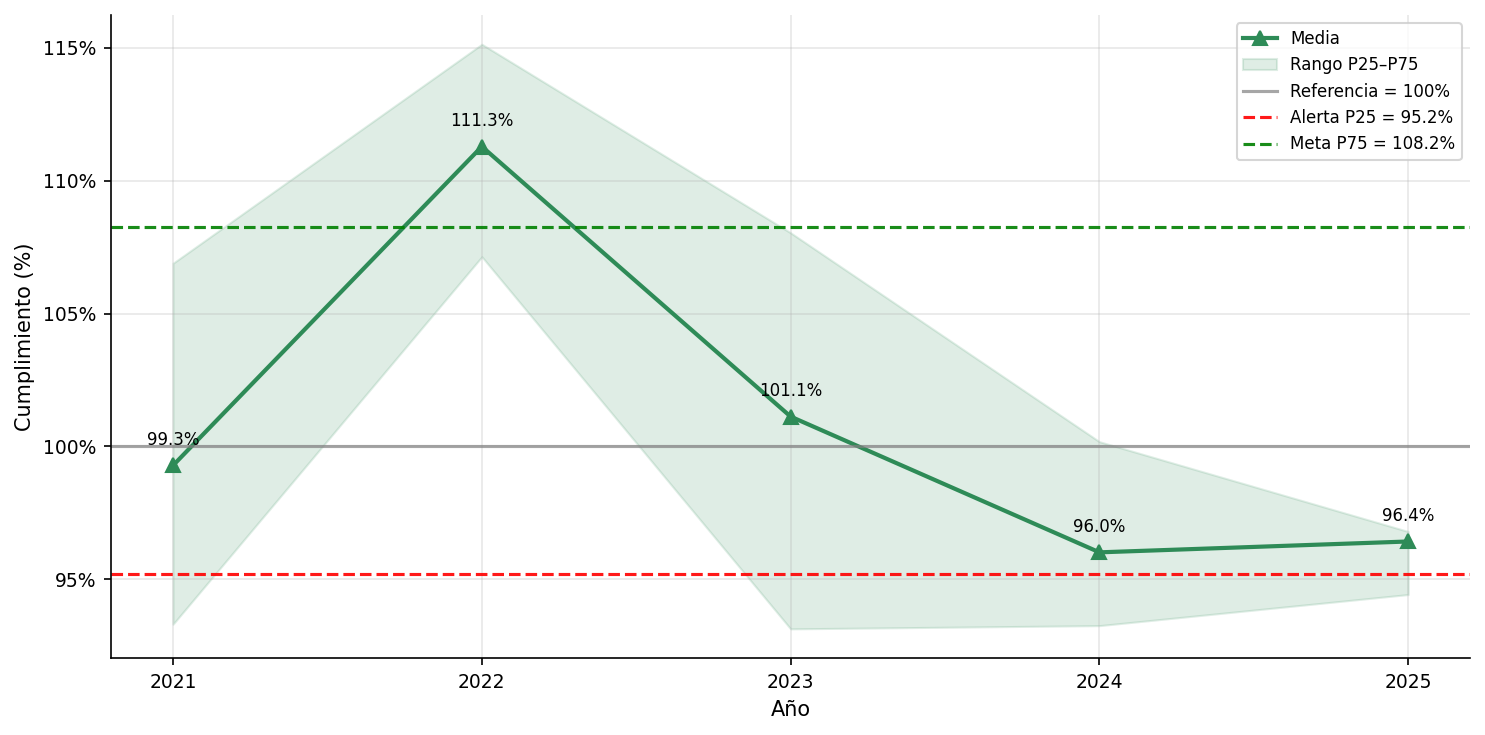

Guardado: Figura5_Cumplimiento.png


In [25]:
# Gráfico Cumplimiento de Proyección por año
fig, ax = plt.subplots(figsize=(10, 5))

# Calculamos medidas de tendencia central (media, mediana) y dispersión (P25, P75)
# para visualizar la proyección a través del tiempo.
cum_yr = mc.groupby('Año')['cumplimiento'].agg(
    mediana='median', media='mean',
    p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
).reset_index()

# TRAZADO DE LA LÍNEA PRINCIPAL (DESEMPEÑO PROMEDIO)
ax.plot(cum_yr['Año'], cum_yr['media']*100, marker='^', color=COLORES[2], lw=2, ms=7, label='Media')

# REPRESENTACIÓN DEL ÁREA DE DISPERSIÓN (Banda de Confianza Operativa)
# El sombreado entre P25 y P75 permite visualizar el rango donde cae el 50% central
# de los sorteos, facilitando la identificación de años con mayor volatilidad.
ax.fill_between(cum_yr['Año'], cum_yr['p25']*100, cum_yr['p75']*100,
                alpha=0.15, color=COLORES[2], label='Rango P25–P75')

# LÍNEAS DE REFERENCIA ESTRATÉGICA (Benchmarking)
ax.axhline(100,           color='gray',  ls='-',  lw=1.5, alpha=0.7, label='Referencia = 100%')
ax.axhline(cum_p25*100,   color='red',   ls='--', lw=1.5, alpha=0.9,
           label=f'Alerta P25 = {cum_p25*100:.1f}%')
ax.axhline(cum_p75*100,   color='green', ls='--', lw=1.5, alpha=0.9,
           label=f'Meta P75 = {cum_p75*100:.1f}%')

# Inserción de etiquetas de valor sobre los puntos de la media para lectura directa.
for _,row in cum_yr.iterrows():
    ax.annotate(f'{row["media"]*100:.1f}%', (row['Año'], row['media']*100),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

# Título y subtítulo por fuera del gráfico (para no repetir en el informe)
print('Cumplimiento de Proyección: evolución de la media por año')
print('Lotería de Cundinamarca, 2021–2025')
#ax.set_title('Cumplimiento de Proyección: evolución de la media por año\nLotería de Cundinamarca, 2021–2025',
#             fontweight='bold')

ax.set_xlabel('Año'); ax.set_ylabel('Cumplimiento (%)')
# Forzar a que los años sean enteros y solo se muestren los presentes en los datos
ax.set_xticks(cum_yr['Año'].unique())
# Aplicación de formato porcentual al eje Y para mayor claridad técnica
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('Figura5_Cumplimiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: Figura5_Cumplimiento.png')

##### Análisis de Resultados: KPI-PLA-01 — Cumplimiento de Proyección

#### 1. Diagnóstico de la Planeación Institucional
* **Calibración Histórica:** La mediana histórica del **100.3%** revela una precisión excepcional en los modelos de proyección de la Lotería. Este valor indica que, en el largo plazo, el cumplimiento exacto de la meta es la norma, validando la metodología técnica de planeación.
* **Consistencia Operativa:** El Coeficiente de Variación (CV) del **9.5%** confirma que el proceso de ventas es estable y que las desviaciones respecto a la proyección son mínimas y controladas.

#### 2. Análisis de Ciclos y Tendencias (2021–2025)
* **Pico de Desempeño (2022):** Se registró un cumplimiento promedio del **111.3%**. Este hito superó incluso el umbral de excelencia (P75), reflejando un periodo donde la demanda del mercado sobrepasó significativamente las expectativas institucionales.
* **Fase de Contracción Reciente (2024–2025):** Se observa una tendencia a la baja con promedios de **96.0%** y **96.4%** respectivamente. Aunque estos valores se mantienen dentro de la zona de control, el hecho de que la media se ubique sistemáticamente por debajo del 100% sugiere una ligera sobreestimación de las metas frente a la realidad actual del mercado.

#### 3. Estructura de Control (Semáforo de Gestión)
Basado en el análisis intercuartílico, se definen los siguientes rangos de acción para el tablero de control:

| Estado | Rango de Cumplimiento | Interpretación Técnica |
| :--- | :---: | :--- |
| **Meta (Verde)** | **> 108.2%** | Desempeño superior al percentil 75 histórico. |
| **Satisfactorio** | **95.2% - 108.2%** | Zona de control normal (Rango P25–P75). |
| **Alerta (Rojo)** | **< 95.2%** | Incumplimiento crítico; requiere revisión de la proyección. |

> **Conclusión Estratégica:**
> Los resultados de **2024 y 2025** se encuentran muy cerca del umbral de alerta (**95.2%**). Esto justifica una recomendación administrativa para **recalibrar los modelos de proyección** del próximo ciclo, ajustando las expectativas de venta a la tendencia de mercado observada en el último bienio.

---
## **Sección 6.3 — Validación Estadística y Operativa de KPIs**

### 6.3.1 — Validación estadística

Se aplican cuatro pruebas en secuencia:
1. **Shapiro-Wilk** — verificar normalidad (justifica elección de Spearman vs. Pearson)
2. **Spearman** — verificar independencia informacional entre KPIs (umbral |r| ≥ 0,90)
3. **ANOVA de un factor** — verificar capacidad discriminativa de cada KPI
4. **Prueba t de una muestra** — verificar que las metas propuestas representen un reto real

#### **Test de Shapiro-Wilk**

**Cómo interpretar W:** El estadístico W toma valores entre 0 y 1. Cuanto más cerca de 1, más compatible es la distribución con la normalidad. Un W bajo (< 0,90) con p < 0,05 indica desviación significativa de la normalidad y justifica el uso de pruebas no paramétricas como Spearman.

In [15]:
# Shapiro-Wilk: verificación de normalidad
# Hipótesis nula H0: la distribución es normal
# Si p < 0.05: se rechaza H0 → distribución NO normal → usar Spearman (no paramétrico)
# Si p >= 0.05: no se rechaza H0 → distribución compatible con normalidad

# NOTA METODOLÓGICA: Los resultados pueden variar ligeramente entre ejecuciones si no se fija la semilla.
np.random.seed(42)  # semilla para reproducibilidad

# NOTA: el test se aplica sobre muestra aleatoria de n=50 porque el test pierde potencia
# con muestras grandes (cualquier desviación mínima resulta significativa con n grande)
series_sw = [
    ('TVE%',                    df_tve['TVE'].sample(50)),
    ('HHI Territorial',         hhi['HHI'].sample(50)),
    ('Cumplimiento Proyección',  mc['cumplimiento'].sample(50)),
    ('Productividad (activos)',  prod_activos['productividad'].sample(50)),
]

print('Prueba de Shapiro-Wilk (n=50 por KPI, semilla=42)')
print(f'{"KPI":<38} {"W":>8} {"p-valor":>10}  Resultado')
print('-'*75)
resultados_sw = {}
for nombre, serie in series_sw:
    w, p_sw = stats.shapiro(serie)
    normal = p_sw >= ALPHA
    dist = 'Normal' if normal else 'No normal = Spearman justificado'
    resultados_sw[nombre] = normal
    print(f'{nombre:<38} {w:>8.4f} {p_sw:>10.4f}  {dist}')

n_no_normal = sum(1 for v in resultados_sw.values() if not v)

Prueba de Shapiro-Wilk (n=50 por KPI, semilla=42)
KPI                                           W    p-valor  Resultado
---------------------------------------------------------------------------
TVE%                                     0.9776     0.4561  Normal
HHI Territorial                          0.8210     0.0000  No normal = Spearman justificado
Cumplimiento Proyección                  0.9527     0.0440  No normal = Spearman justificado
Productividad (activos)                  0.1985     0.0000  No normal = Spearman justificado


##### Hallazgos: Test de Shapiro-Wilk

Los valores W obtenidos confirman la decisión metodológica de usar Spearman: tres de los cuatro KPIs rechazan la hipótesis de normalidad (p < 0,05).

- **TVE%** (W = 0,978; p = 0,456): no rechaza normalidad con la semilla fija. Es el único KPI con distribución compatible con la normal, aunque su comportamiento mostró sensibilidad a la selección de muestra en pruebas previas.
- **HHI Territorial** (W = 0,821; p < 0,001): distribución no normal. La concentración territorial presenta colas largas por sorteos atípicos de alta concentración.
- **Cumplimiento de Proyección** (W = 0,953; p = 0,044): marginalmente no normal. El valor p cercano al umbral refleja una distribución casi simétrica pero con ligera asimetría en los extremos.
- **Productividad por Distribuidor** (W = 0,199; p < 0,001): la desviación más extrema de la normalidad del conjunto, consistente con el CV de 333% observado en la distribución de distribuidores activos. La asimetría positiva es muy pronunciada por los distribuidores de alta productividad.

La no normalidad predominante (3 de 4 KPIs) justifica el uso de Spearman como prueba de asociación para todo el sistema, en lugar del coeficiente de Pearson.

#### **Prueba de Spearman**

**Cómo interpretar r:** El coeficiente de Spearman r varía entre −1 y +1. Valores cercanos a 0 indican independencia; valores cercanos a ±1 indican asociación perfecta. El umbral de redundancia adoptado es |r| ≥ 0,90, equivalente a que ambos KPIs compartan más del 81% de su varianza (r²). Un par que supere ese umbral no aporta información adicional al sistema.

In [16]:
# Spearman: verificación de no redundancia
# Un par de KPIs es REDUNDANTE si |r| >= 0.90 (Murad et al., 2022, pág. 6)
# Justificación del umbral: r = 0.90 → r² = 0.81 → ambos KPIs comparten
# más del 81% de su varianza explicada; uno puede sustituir al otro.

# Verificación previa: TVE vs IR (redundancia que justificó el descarte del IR)
df_ir = df.groupby('Sorteo').agg(
    v  =('Fracciones vendidas',  'sum'),
    d  =('Fracciones despachadas','sum'),
    dev=('Fracciones devueltas',  'sum')
).reset_index()
df_ir['TVE'] = df_ir['v']   / df_ir['d']
df_ir['IR']  = df_ir['dev'] / df_ir['d']
suma_promedio = (df_ir['TVE'] + df_ir['IR']).mean()
r_ir, _ = stats.spearmanr(df_ir['TVE'], df_ir['IR'])
print(f'Verificación previa: TVE% + IR = {suma_promedio:.6f} (complementos exactos)')
print(f'Spearman TVE vs IR: r = {r_ir:.3f}  → |r| >= {UMBRAL_REDUNDANCIA}: REDUNDANTES (descarte del IR justificado)')
print()

# Tabla de correlaciones entre KPIs seleccionados
df_sp = df_tve[['Sorteo','TVE']].merge(hhi[['Sorteo','HHI']], on='Sorteo')
df_sp = df_sp.merge(
    mc[['sorteo','cumplimiento']].rename(columns={'sorteo':'Sorteo'}), on='Sorteo', how='left'
)

# NOTA: TVE% se calcula a nivel distribuidor (TVE_d) para poder comparar
# con Productividad, que también está a nivel distribuidor.
# El resultado puede diferir del par TVE%-sorteo porque la granularidad es distinta.
tve_dist = df.groupby('Distribuidor').agg(
    v=('Fracciones vendidas','sum'), d=('Fracciones despachadas','sum')
).reset_index()

tve_dist['TVE_d'] = tve_dist['v'] / tve_dist['d']
# Se usa el universo completo (412 distribuidores) para la prueba de Spearman
prod_sp = prod[['Distribuidor','productividad']].merge(
    tve_dist[['Distribuidor','TVE_d']], on='Distribuidor'
)

print(f'Correlaciones de Spearman entre KPIs seleccionados')
print(f'Umbral de redundancia: |r| >= {UMBRAL_REDUNDANCIA}  (Murad et al., 2022, pág. 6)')
print(f'{"Par de KPIs":<48} {"N":>5} {"r":>8} {"p":>10}  Resultado')
print('-'*88)

pares = [
    ('TVE% vs HHI Territorial',              'TVE','HHI',          df_sp),
    ('TVE% vs Cumplimiento de Proyección',   'TVE','cumplimiento',  df_sp),
    ('HHI vs Cumplimiento de Proyección',    'HHI','cumplimiento',  df_sp),
    ('TVE% vs Productividad (nivel dist.)',  'TVE_d','productividad', prod_sp),
]
for etiq, a, b, src in pares:
    sub = src[[a,b]].dropna()
    r, p = stats.spearmanr(sub[a], sub[b])
    res = 'Independientes' if abs(r) < UMBRAL_REDUNDANCIA else 'REDUNDANTES'
    print(f'{etiq:<48} {len(sub):>5} {r:>+8.3f} {p:>10.4f}  {res}')

print()
print('Nota: HHI vs Productividad no se calcula directamente porque tienen distinta granularidad')
print('(HHI = nivel sorteo | Productividad = nivel distribuidor).')

Verificación previa: TVE% + IR = 1.000001 (complementos exactos)
Spearman TVE vs IR: r = -1.000  → |r| >= 0.9: REDUNDANTES (descarte del IR justificado)

Correlaciones de Spearman entre KPIs seleccionados
Umbral de redundancia: |r| >= 0.9  (Murad et al., 2022, pág. 6)
Par de KPIs                                          N        r          p  Resultado
----------------------------------------------------------------------------------------
TVE% vs HHI Territorial                            272   -0.096     0.1146  Independientes
TVE% vs Cumplimiento de Proyección                 226   +0.663     0.0000  Independientes
HHI vs Cumplimiento de Proyección                  226   +0.128     0.0539  Independientes
TVE% vs Productividad (nivel dist.)                412   +0.542     0.0000  Independientes

Nota: HHI vs Productividad no se calcula directamente porque tienen distinta granularidad
(HHI = nivel sorteo | Productividad = nivel distribuidor).


##### Hallazgos: Verificación de no redundancia (Spearman)

La prueba de Spearman confirma que los cuatro KPIs seleccionados conforman un sistema informativamente no redundante: ningún par supera el umbral de |r| ≥ 0,90 establecido como criterio de descarte (Murad et al., 2022).

La correlación más elevada se observa entre TVE% y Cumplimiento de Proyección (r = +0,663), resultado operativamente interpretable: los sorteos con mayor conversión de venta tienden a registrar también mayor cumplimiento de la proyección institucional, dado que ambos responden al mismo fenómeno generador — el desempeño de la red en el período. Sin embargo, la magnitud está lejos del umbral de descarte, lo que confirma que ambas métricas aportan información diagnóstica diferenciada.

La correlación entre TVE% y Productividad (r = +0,542, calculada a nivel distribuidor) es positiva y significativa, pero moderada, lo que confirma independencia estadística entre ambos KPIs bajo la fórmula institucional vigente.

**Implicación:** Los cuatro KPIs pueden coexistir en el sistema de medición sin redundancia informacional.

#### **Pruebas ANOVA**

**Cómo interpretar F:** El estadístico F es el cociente entre la varianza entre grupos y la varianza dentro de grupos. Un F = 1 indicaría que el KPI no distingue entre períodos; cuanto mayor el F, mayor es la diferencia relativa entre grupos respecto a la variación interna. El p-valor indica la probabilidad de obtener ese F (o mayor) si en realidad no hubiera diferencias. Con p < 0,05 se concluye que las diferencias son reales y no atribuibles al azar.

In [17]:
# ANOVA: capacidad discriminativa por año
# H0: las medias del KPI son iguales en todos los años
# Si p < 0.05: se rechaza H0 = el KPI detecta diferencias significativas entre períodos
# F = varianza entre grupos / varianza dentro de grupos
# F grande con p < 0.05 indica que la variación entre años es real, no producto del azar

# Nota: Productividad no se incluye en esta tabla porque su función principal es la comparación
# entre distribuidores dentro de un período, no la evaluación temporal agregada

# TVE por año
g_tve_a = [g['TVE'].values for _,g in df_tve.groupby('Año')]
f1, p1 = stats.f_oneway(*g_tve_a)

# TVE por departamento (top 10 por volumen)
top10d = df.groupby('Departamento')['Neto vendido'].sum().nlargest(10).index
df_dtve = df[df['Departamento'].isin(top10d)].groupby(['Sorteo','Departamento']).agg(
    v=('Fracciones vendidas','sum'), d=('Fracciones despachadas','sum')
).reset_index()

df_dtve['TVE'] = df_dtve['v'] / df_dtve['d']
g_tve_d = [g['TVE'].values for _,g in df_dtve.groupby('Departamento') if len(g)>=3]
f2, p2 = stats.f_oneway(*g_tve_d)

# HHI por año
g_hhi_a = [g['HHI'].values for _,g in hhi.groupby('Año')]
f3, p3 = stats.f_oneway(*g_hhi_a)

# Cumplimiento por año
g_cum_a = [g['cumplimiento'].values for _,g in mc.groupby('Año') if len(g)>1]
f5, p5 = stats.f_oneway(*g_cum_a)

print('ANOVA de un factor (α = 0.05)')
print(f'{"KPI":<35} {"Factor":<16} {"N grupos":>8} {"N obs":>7} {"F":>10} {"p-valor":>12}  Decisión')
print('-'*105)
resultados_anova = [
    ('TVE%',                       'Año',           len(g_tve_a),  len(df_tve),      f1, p1),
    ('TVE%',                       'Departamento',  len(g_tve_d),  len(df_dtve),     f2, p2),
    ('HHI Territorial',            'Año',           len(g_hhi_a),  len(hhi),         f3, p3),
    ('Cumplimiento Proyección',    'Año',           len(g_cum_a),  len(mc),           f5, p5),
]
for kpi,factor,ng,nobs,f,p in resultados_anova:
    dec = 'Discrimina' if p < ALPHA else 'No discrimina'
    print(f'{kpi:<35} {factor:<16} {ng:>8} {nobs:>7} {f:>10.3f} {p:>12.2e}  {dec}')

print()
print('Medias por año:')
print('\nTVE%:')
for año,g in df_tve.groupby('Año'): print(f'  {int(año)}: {g["TVE"].mean()*100:.2f}%')
print('\nHHI:')
for año,g in hhi.groupby('Año'): print(f'  {int(año)}: {g["HHI"].mean()*100:.2f}%')
print('\nCumplimiento:')
for año,g in mc.groupby('Año'): print(f'  {int(año)}: {g["cumplimiento"].mean()*100:.1f}%')

ANOVA de un factor (α = 0.05)
KPI                                 Factor           N grupos   N obs          F      p-valor  Decisión
---------------------------------------------------------------------------------------------------------
TVE%                                Año                     6     272     39.434     3.05e-30  Discrimina
TVE%                                Departamento           10    2720    200.675    9.52e-293  Discrimina
HHI Territorial                     Año                     6     272     90.615     2.13e-55  Discrimina
Cumplimiento Proyección             Año                     5     226     29.415     1.29e-19  Discrimina

Medias por año:

TVE%:
  2020: 18.62%
  2021: 24.18%
  2022: 26.70%
  2023: 25.76%
  2024: 22.43%
  2025: 22.98%

HHI:
  2020: 15.85%
  2021: 14.19%
  2022: 13.40%
  2023: 13.62%
  2024: 13.26%
  2025: 13.06%

Cumplimiento:
  2021: 99.3%
  2022: 111.3%
  2023: 101.1%
  2024: 96.0%
  2025: 96.4%


##### Hallazgos: Capacidad discriminativa (ANOVA de un factor)

Los tres KPIs sometidos a esta prueba superaron el criterio de significancia (α = 0,05):

**TVE%** registró diferencias altamente significativas entre años (F = 39,4; p < 0,001), con el mayor contraste entre 2020 (media 18,62%) — año de baja post-pandemia — y 2022 (26,70%), pico de recuperación. La contracción sostenida hacia 22,43% en 2024 coincide con el I.R.V.E. de 0,82 reportado por la entidad ese año. El ANOVA por departamento (F = 200,7; p < 0,001) confirma adicionalmente que la TVE% varía de forma significativa entre territorios, evidenciando heterogeneidad en la capacidad de conversión de la red.

**HHI Territorial** registró la mayor significancia estadística del conjunto (F = 90,6; p < 0,001) con una tendencia sistemática de reducción desde la media de 15,85% en 2020 hasta 13,06% en 2025, señal de diversificación territorial progresiva de las ventas.

**Cumplimiento de Proyección** mostró diferencias significativas entre años (F = 29,4; p < 0,001), con el pico en 2022 (111,3%) y la contracción más pronunciada en 2024 (96,0%).

**Productividad por Distribuidor** no se incluyó en esta tabla dado el diseño del KPI como herramienta de comparación entre distribuidores (no entre períodos), su validación se limita a la prueba de Spearman conforme al protocolo de la sección 5.3.1.

#### **Pruebas ***t*****

**Cómo interpretar t:** El estadístico ***t*** mide cuántas desviaciones estándar separan la media histórica de la meta propuesta. Un ***t*** negativo (como en TVE%) indica que la meta está por encima de la media histórica — es decir, es retadora. Un t positivo (como en HHI) indica que la meta está por debajo de la media — también es retadora, dado que HHI se minimiza. El p-valor confirma que esa diferencia es estadísticamente real (p < 0,05) y no producto del azar.

In [18]:
# Prueba t de una muestra: solidez de las metas
# La meta de cada KPI se fija en P75 (maximizados) o P25 (minimizados)
# La prueba t verifica si la meta es DIFERENTE de la media histórica:
#   p < 0.05: la meta es estadísticamente distinta de la media = reto real de mejora
#   p >= 0.05: la meta coincide con la media histórica = sería un objetivo trivial

meta_tve = tve.quantile(0.75)
meta_hhi = h.quantile(0.25)
meta_cum = 1.00

print('Prueba t de una muestra: solidez de las metas propuestas')
print(f'{"KPI":<35} {"Meta":<28} {"Media hist.":>12} {"t":>8} {"p":>10}  Resultado')
print('-'*107)

for kpi, vals, meta, meta_txt in [
    ('TVE%  (maximizar)',           tve, meta_tve, f'>= P75 = {meta_tve*100:.1f}%'),
    ('HHI  (minimizar)',            h,   meta_hhi, f'<= P25 = {meta_hhi*100:.2f}%'),
    ('Cumplimiento  (maximizar)',   c,   meta_cum,  '= 100%'),
]:
    t, p = stats.ttest_1samp(vals.dropna(), meta)
    media_txt = f'{vals.mean()*100:.2f}%'
    res = 'Meta retadora' if p < ALPHA else 'Meta coincide con la media — revisar'
    print(f'{kpi:<35} {meta_txt:<28} {media_txt:>12} {t:>+8.3f} {p:>10.4f}  {res}')

Prueba t de una muestra: solidez de las metas propuestas
KPI                                 Meta                          Media hist.        t          p  Resultado
-----------------------------------------------------------------------------------------------------------
TVE%  (maximizar)                   >= P75 = 26.2%                     23.62%  -10.449     0.0000  Meta retadora
HHI  (minimizar)                    <= P25 = 13.24%                    13.95%  +10.130     0.0000  Meta retadora
Cumplimiento  (maximizar)           = 100%                            101.46%   +2.277     0.0237  Meta retadora


##### Hallazgos: Solidez estadística de metas (prueba t de una muestra)

Las metas propuestas para los tres KPIs validados con prueba t muestran diferente naturaleza:

**TVE% y HHI** presentan metas retadoras (p < 0,001): la meta del P75 para TVE% (≥26,2%) es significativamente superior a la media histórica (23,62%), lo que implica que alcanzarla requiere un desempeño superior al promedio observado en el período 2020–2025. De manera análoga, la meta del P25 para HHI (≤13,24%) es significativamente inferior a la media histórica (13,95%), lo que representa un objetivo de mayor diversificación territorial.

**Cumplimiento de Proyección** presenta una meta estadísticamente compatible con el desempeño histórico (p = 0,024; media histórica 101,46% vs meta 100%), lo que indica que la meta de ≥100% es alcanzable bajo condiciones normales de operación, pero no trivial.

**Productividad** no se incluye en esta tabla porque su función principal es la comparación entre distribuidores dentro de un período, no la evaluación temporal agregada. Sus umbrales semáforo (P25/P75 de distribuidores activos) cumplen la función de referencia institucional sin requerir validación formal mediante prueba t.